In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [2]:
blazar_coord = SkyCoord.from_name("Mrk 501")
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


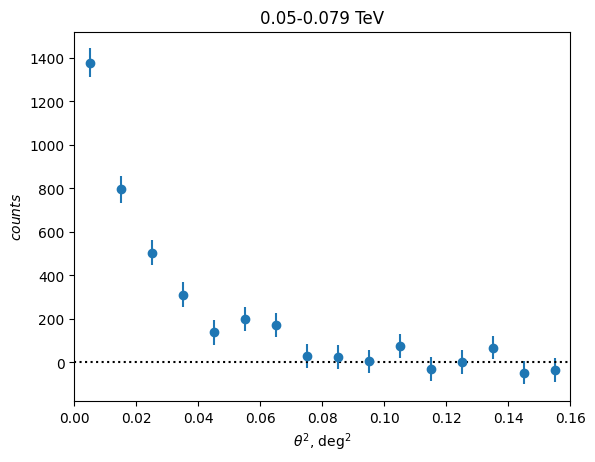

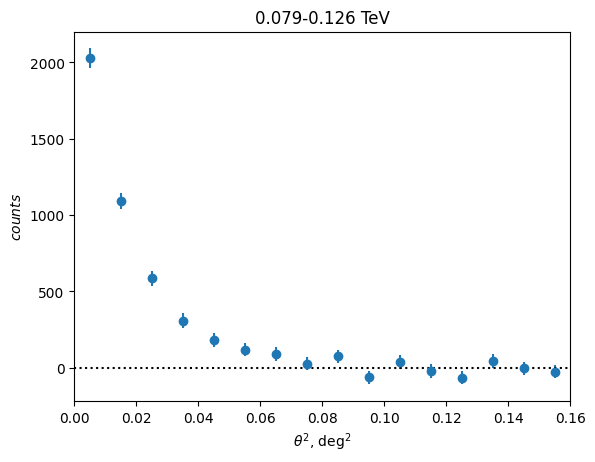

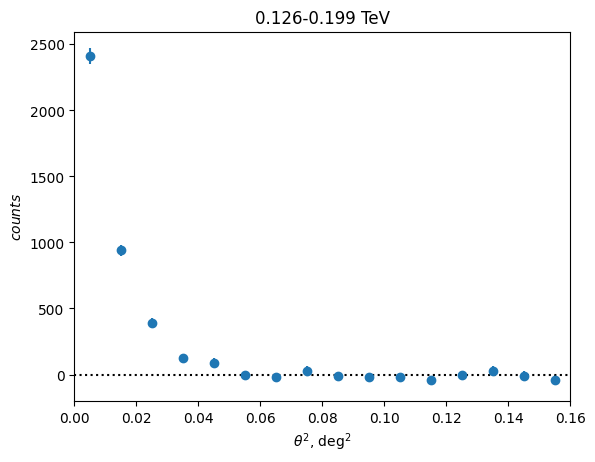

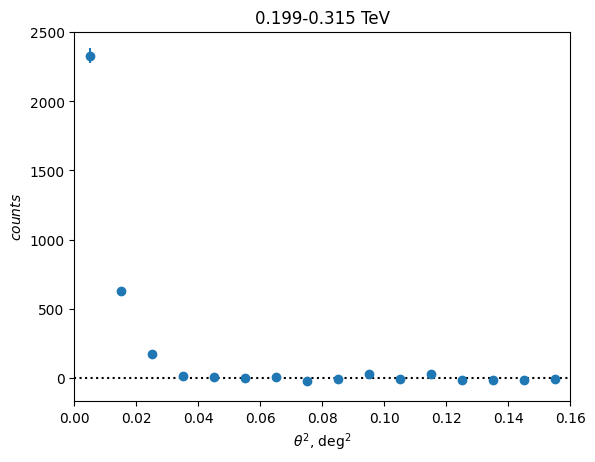

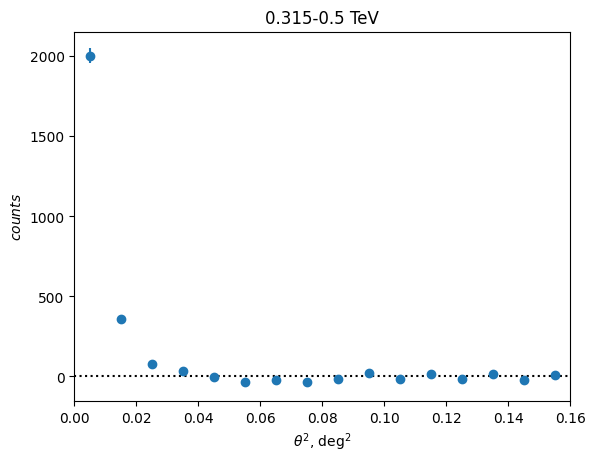

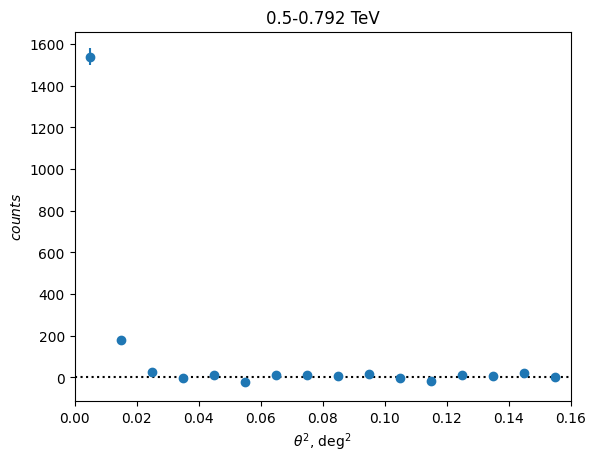

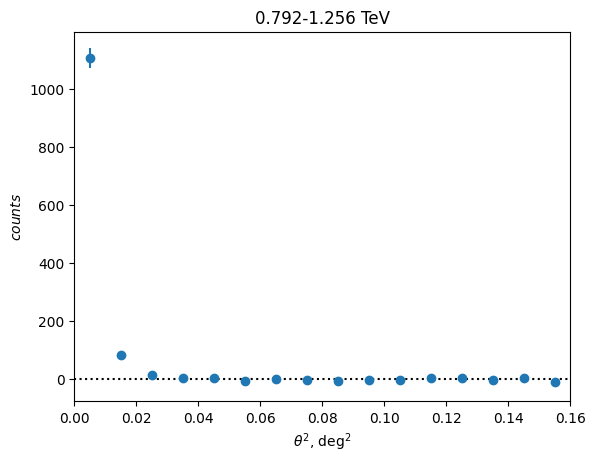

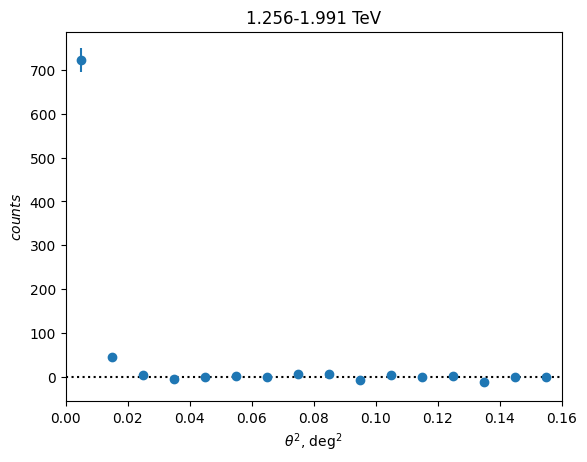

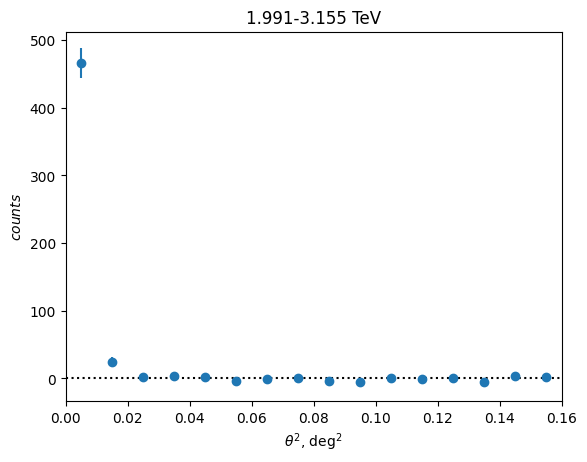

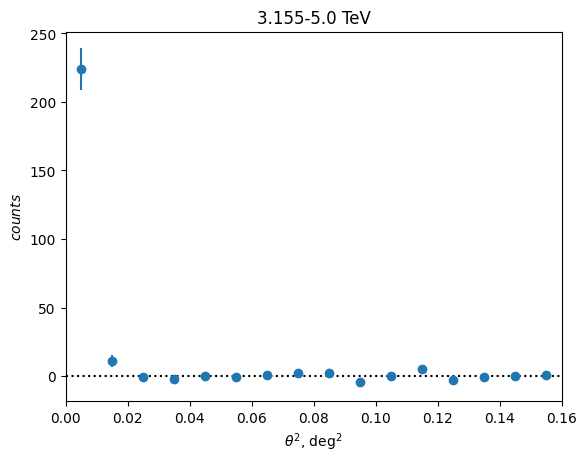

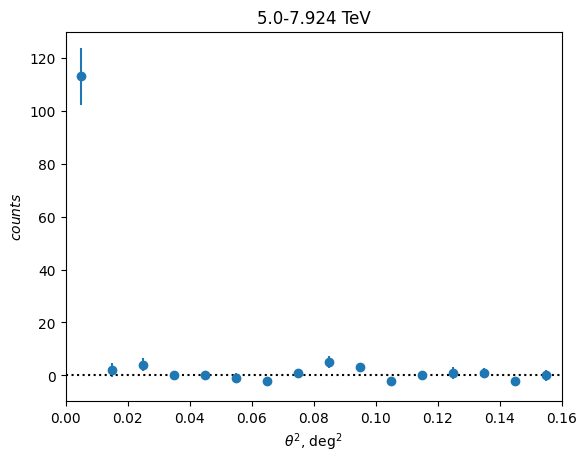

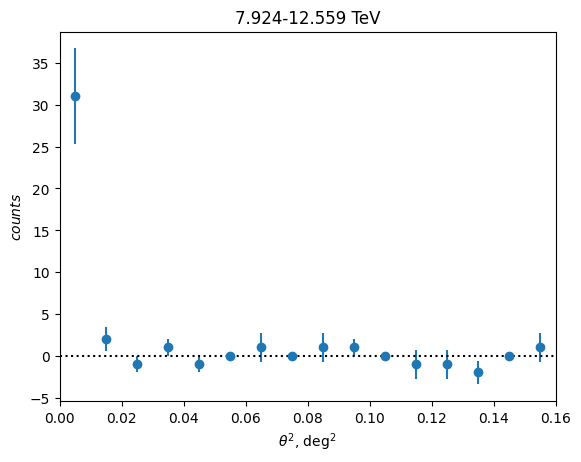

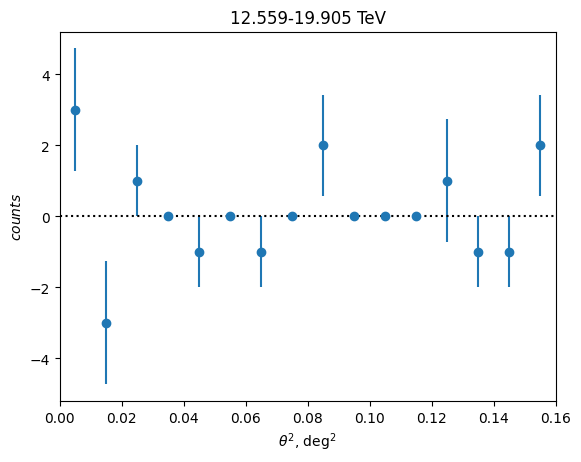

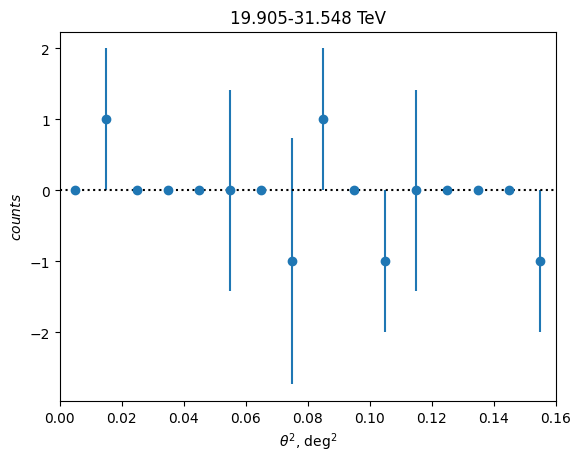

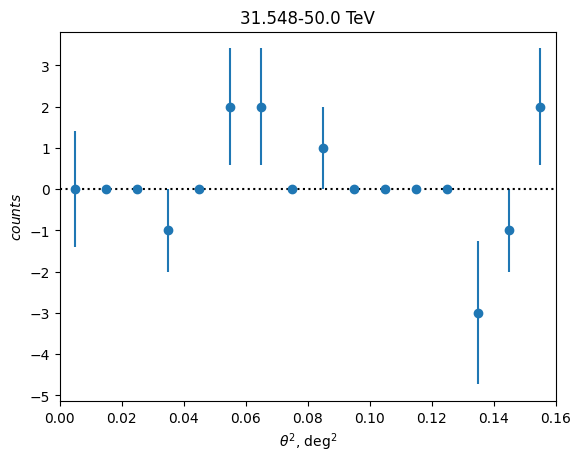

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)

for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
psf_hbu = irf["psf"]
print(psf_hbu)
print(psf_hbu.info())
print(psf_hbu.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

3


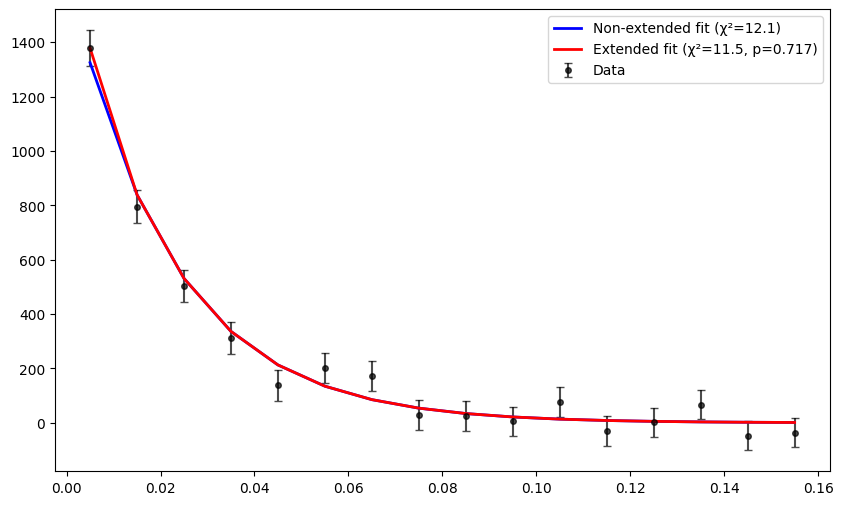

4


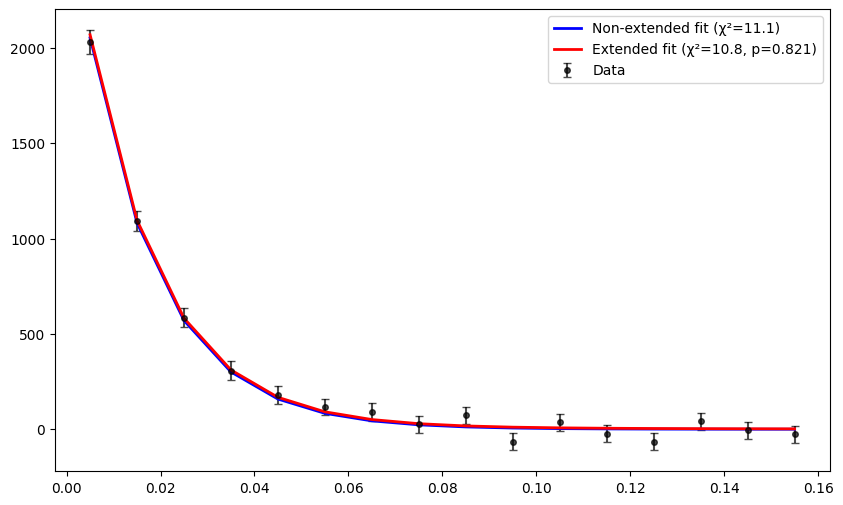

5


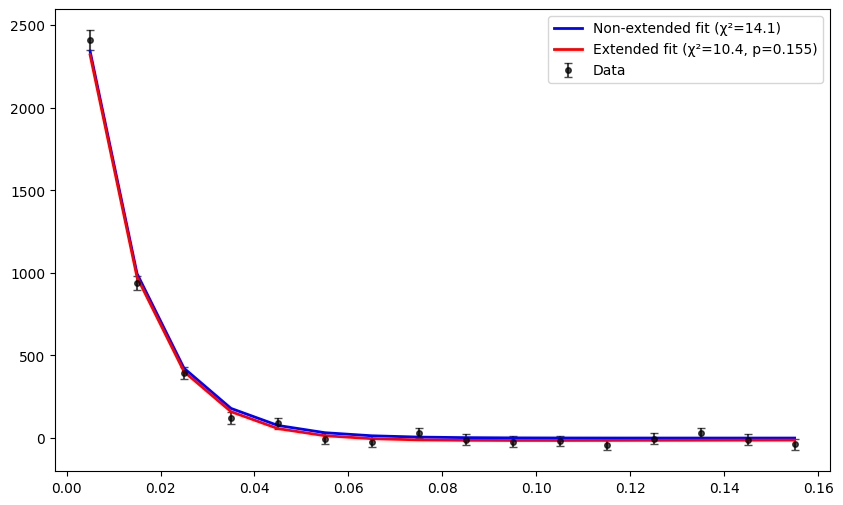

6


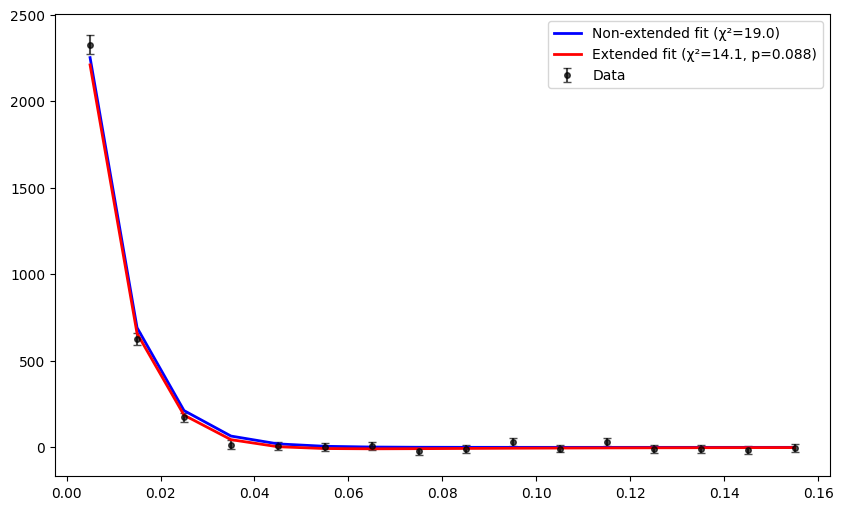

7


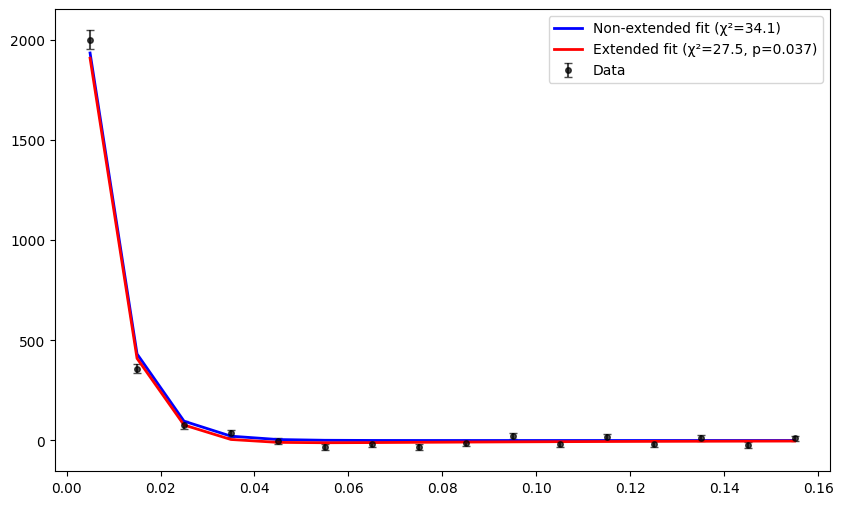

8


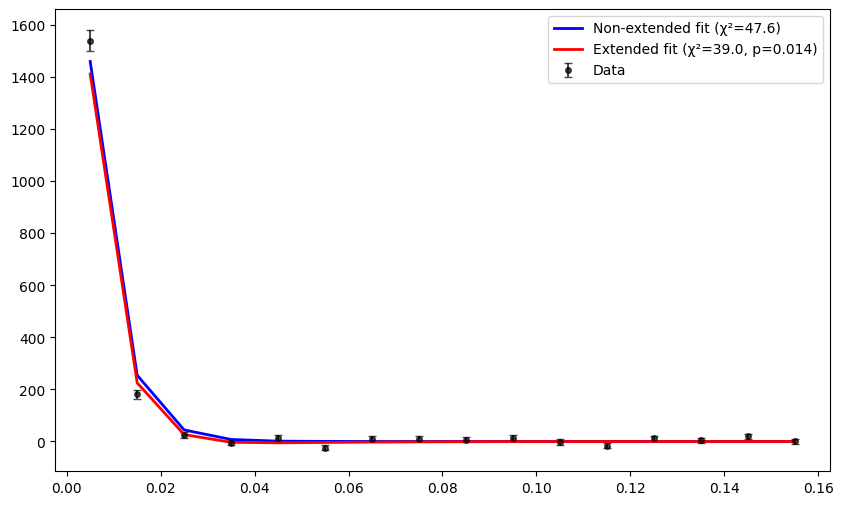

9


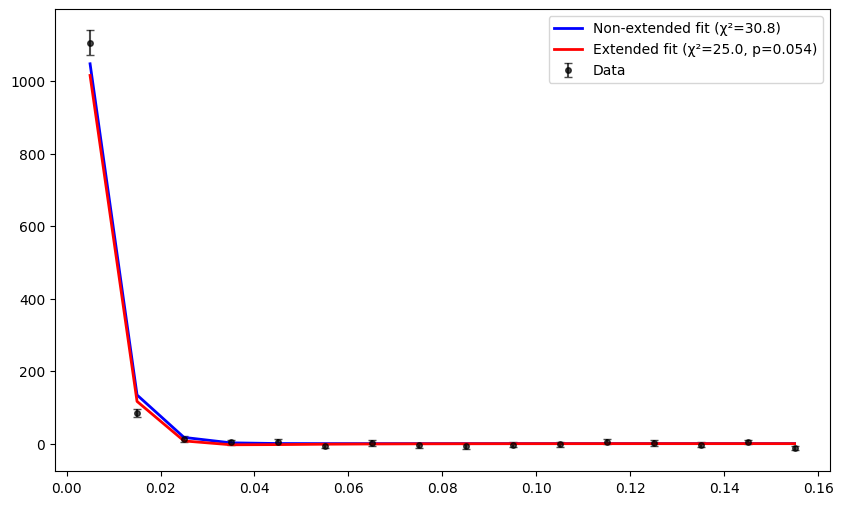

10


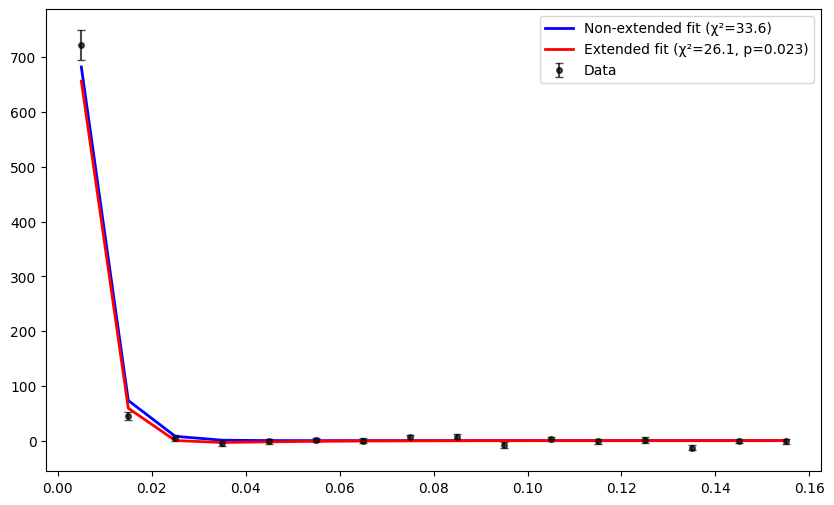

11


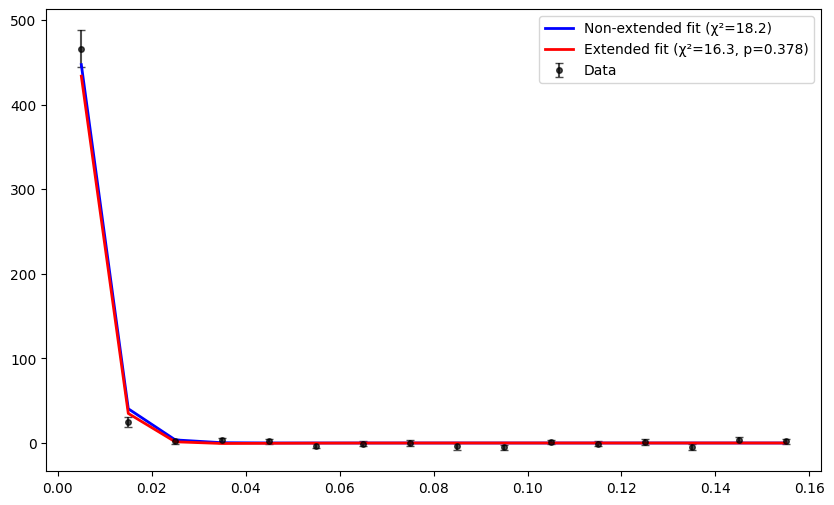

12


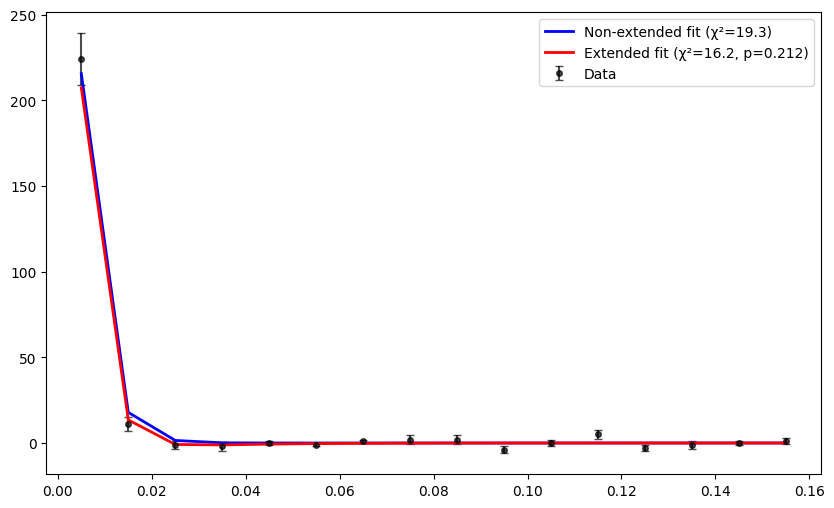

13


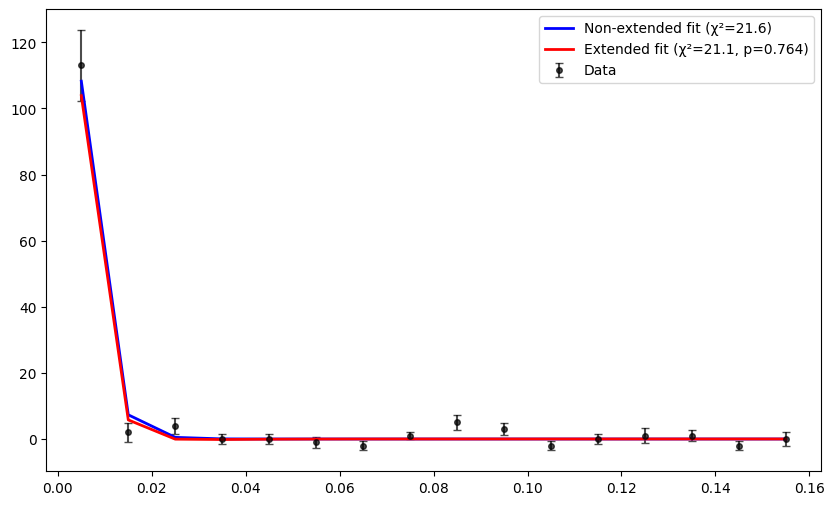

14


/layers/paketo-buildpacks_conda-env-update/conda-env/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_54115/667748469.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_noext, pcov_noext = curve_fit(
/tmp/ipykernel_54115/667748469.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_ext, pcov_ext = curve_fit(
/tmp/ipykernel_54115/667748469.py:47: RuntimeWarning: divide by zero encountered in divide
  chi2_noext = np.sum(((ct - fit_noext) / ct_err) ** 2)
/tmp/ipykernel_54115/667748469.py:48: RuntimeWarning: divide by zero encountered in divide
  chi2_ext = np.sum(((ct - fit_ext) / ct_err) ** 2)
/tmp/ipykernel_54115/667748469.py:49: RuntimeWarning: invalid value encountered in scalar subtract
  delta_chi2 = chi2_noext - chi2_ext


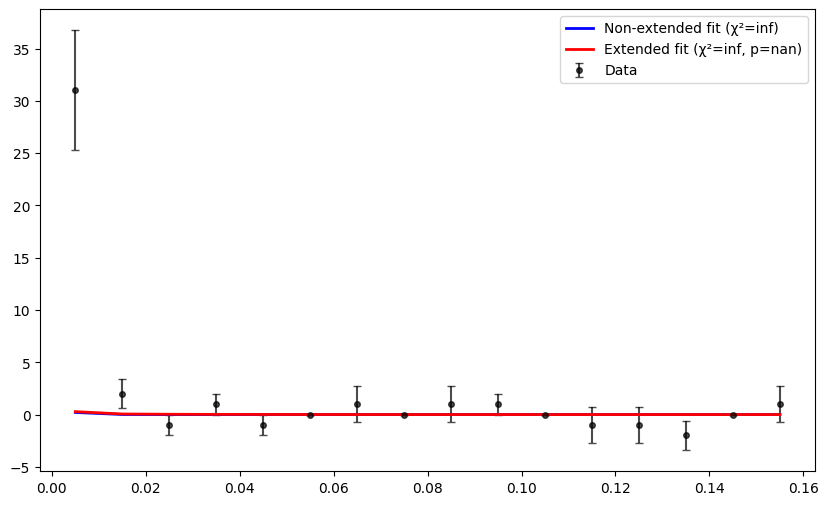

15


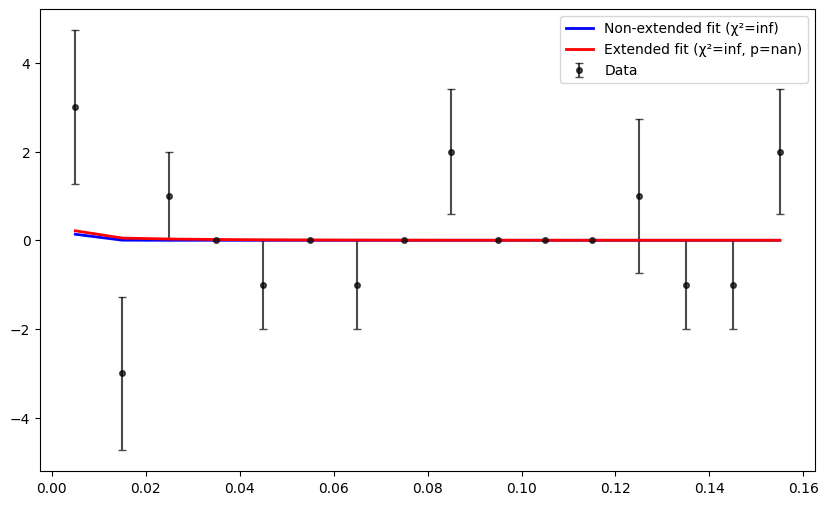

16


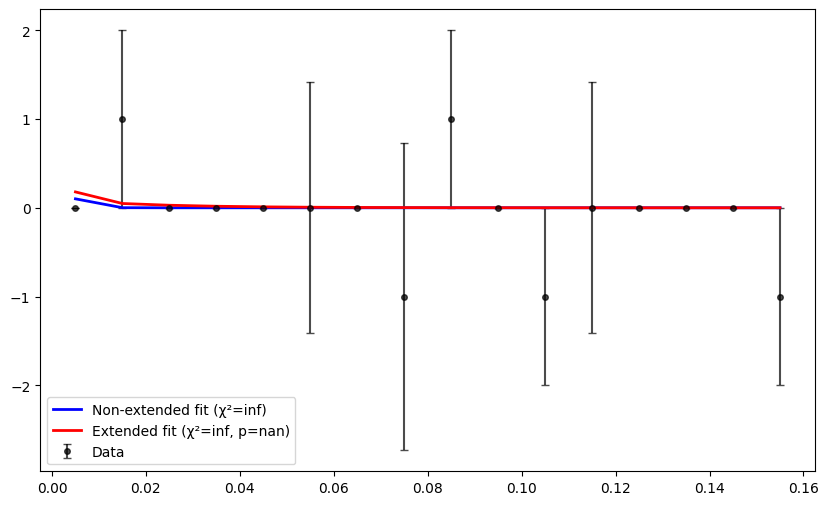

17


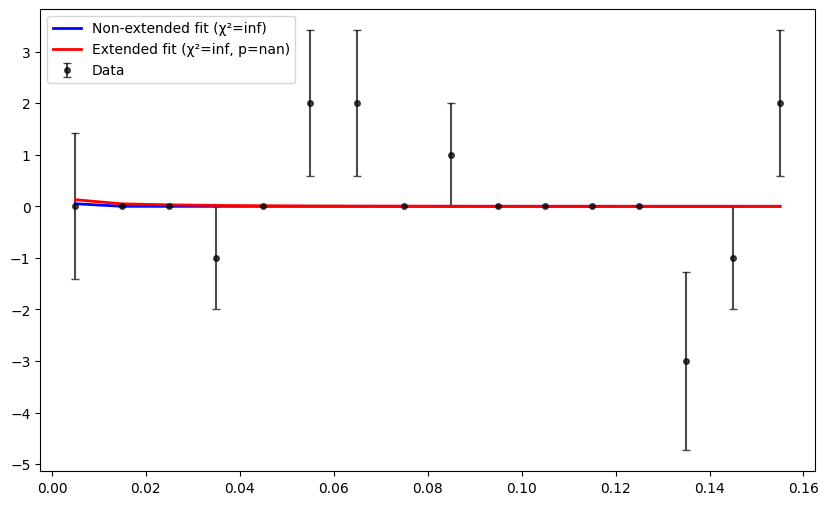

In [12]:
for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
                
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
    def psf_model(th2, norm):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return norm*(gauss1+gauss2+gauss3)
    
    init_guess_noext = [1.0]
    init_guess_ext = [0.1, 0.1]
        
    popt_noext, pcov_noext = curve_fit(
            psf_model,
            th2,
            ct,
            sigma=ct_err,
            p0=init_guess_noext,
            absolute_sigma=True,
            maxfev=10000,
        )
    
    def ext_model(th2, norm_e, sigma_e):
        gauss_ext = norm_e*np.exp(-th2/2/sigma_e**2)
        return psf_model(th2, popt_noext) + gauss_ext
        
    popt_ext, pcov_ext = curve_fit(
            ext_model,
            th2,
            ct,
            sigma=ct_err,
            p0=init_guess_ext,
            absolute_sigma=True,
            maxfev=10000,
        )
    fit_noext = psf_model(th2, *popt_noext)
    fit_ext = ext_model(th2, *popt_ext)
    delta_dof = 2 # here is 2 or 1?????
    chi2_noext = np.sum(((ct - fit_noext) / ct_err) ** 2)
    chi2_ext = np.sum(((ct - fit_ext) / ct_err) ** 2)
    delta_chi2 = chi2_noext - chi2_ext
    p_value = 1 - stats.chi2.cdf(delta_chi2, delta_dof)
    
    plt.figure(figsize=(10, 6))

    plt.errorbar(th2, ct, yerr=ct_err, fmt='o', 
                    markersize=4, capsize=3, capthick=1, 
                    label='Data', color='black', alpha=0.7)
        
    plt.plot(th2, fit_noext, 'b-', linewidth=2, 
                label=f'Non-extended fit (χ²={chi2_noext:.1f})')
        
    plt.plot(th2, fit_ext, 'r-', linewidth=2, 
                label=f'Extended fit (χ²={chi2_ext:.1f}, p={p_value:.3f})')
    plt.legend()
    plt.show()